In [4]:
import torch
from torch.utils.data import DataLoader, Dataset

from lightning import LightningDataModule

from src.data.components.data import FuturePredictionDataset
from omegaconf import DictConfig

In [5]:
from omegaconf import OmegaConf

common = OmegaConf.create({
    'semantic_segmentation': {
        'weights': [1.0, 2.0],
        'use_top_k': True,
        'top_k_ratio': 0.25,
    },
    'receptive_field': 3,
    'future_discount': 0.95,
    'ignore_index': 255,
    'lift': {
        'x_bound': [-50.0, 50.0, 0.5],
        'y_bound': [-50.0, 50.0, 0.5],
        'z_bound': [-10.0, 10.0, 20.0],
        'd_bound': [2.0, 50.0, 1.0],
    },
    'image': {
        'final_dim': [224, 480],
        'resize_scale': 0.3,
        'top_crop': 46,
        'original_height': 900,
        'original_width': 1600,
        'names': ['CAM_FRONT_LEFT', 'CAM_FRONT', 'CAM_FRONT_RIGHT', 'CAM_BACK_LEFT', 'CAM_BACK', 'CAM_BACK_RIGHT'],
    },
})



In [6]:
import os

data_root = '/home/slabban/workspace/bev-hydra/data/nuscenes'


version = 'trainval'

batch_size = 1
filter_invisible_vehicles = True
num_workers = 4
pin_memory = True

device = torch.device('cuda:0')


Create Dataset

In [7]:
data_train = FuturePredictionDataset(
            data_root=data_root, is_train=True, version=version, batch_size=batch_size, filter_invisible_vehicles=filter_invisible_vehicles, common=common
        )

Create DataLoader

In [8]:
data_loader = DataLoader(
            dataset=data_train,
            batch_size=batch_size,
            num_workers=num_workers,
            pin_memory=pin_memory,
            shuffle=True, drop_last= True
        )

Get first batch

In [9]:
len(data_loader)

26730

In [10]:
sample = next(iter(data_loader))

RuntimeError: CUDA unknown error - this may be due to an incorrectly set up environment, e.g. changing env variable CUDA_VISIBLE_DEVICES after program start. Setting the available devices to be zero.

In [8]:
print(sample.keys())

dict_keys(['image', 'intrinsics', 'extrinsics', 'segmentation', 'instance', 'centerness', 'offset', 'flow', 'future_egomotion', 'sample_token', 'z_position', 'attribute'])


_input_: We see the the model inputs, which is a sequence of croppped images, along with their intrinsics, extrinsics, and the translation of ego motion from one frame to the next.
In this case, the input will only be the past 2 frames along with the current frame that will be compared for predictions.

_output labels_: Birds Eye View consisting of segmentation. instances, centerness, offset (from center), future flow (we wont be using this) 

In [9]:
import torch
for key in sample.keys():
    if isinstance(sample[key], torch.Tensor):
        print(key, sample[key].shape)

image torch.Size([1, 3, 6, 3, 224, 480])
intrinsics torch.Size([1, 3, 6, 3, 3])
extrinsics torch.Size([1, 3, 6, 4, 4])
segmentation torch.Size([1, 3, 1, 200, 200])
instance torch.Size([1, 3, 200, 200])
centerness torch.Size([1, 3, 1, 200, 200])
offset torch.Size([1, 3, 2, 200, 200])
flow torch.Size([1, 3, 2, 200, 200])
future_egomotion torch.Size([1, 3, 6])
z_position torch.Size([1, 3, 1, 200, 200])
attribute torch.Size([1, 3, 1, 200, 200])


In [10]:
mean = torch.tensor([0.485, 0.456, 0.406])
std = torch.tensor([0.229, 0.224, 0.225])

def denormalize(tensor, mean, std):
    for t, m, s in zip(tensor, mean, std):
        t.mul_(s).add_(m)
    return tensor

In [11]:
import matplotlib.pyplot as plt
def show_images(images):
    batch_size, sequence_length, num_types, channels, height, width = images.shape
    
    # Assuming batch_size is 1 for simplicity, remove the batch dimension
    images = images[0]
    
    fig, axes = plt.subplots(sequence_length, num_types, figsize=(num_types * 5, sequence_length * 5))
    
    for t in range(sequence_length):
        for i in range(num_types):
            image = images[t, i].permute(1, 2, 0) # Change shape from (3, 224, 480) to (224, 480, 3)
            image = denormalize(image, mean, std)
            # image = image.permute(1, 2, 0).numpy()  
            axes[t, i].imshow(image)
            axes[t, i].axis('off')
            axes[t, i].set_title(f'Seq {t}, Type {common.image.names[i]}')
    
    plt.tight_layout()
    plt.show()


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping i

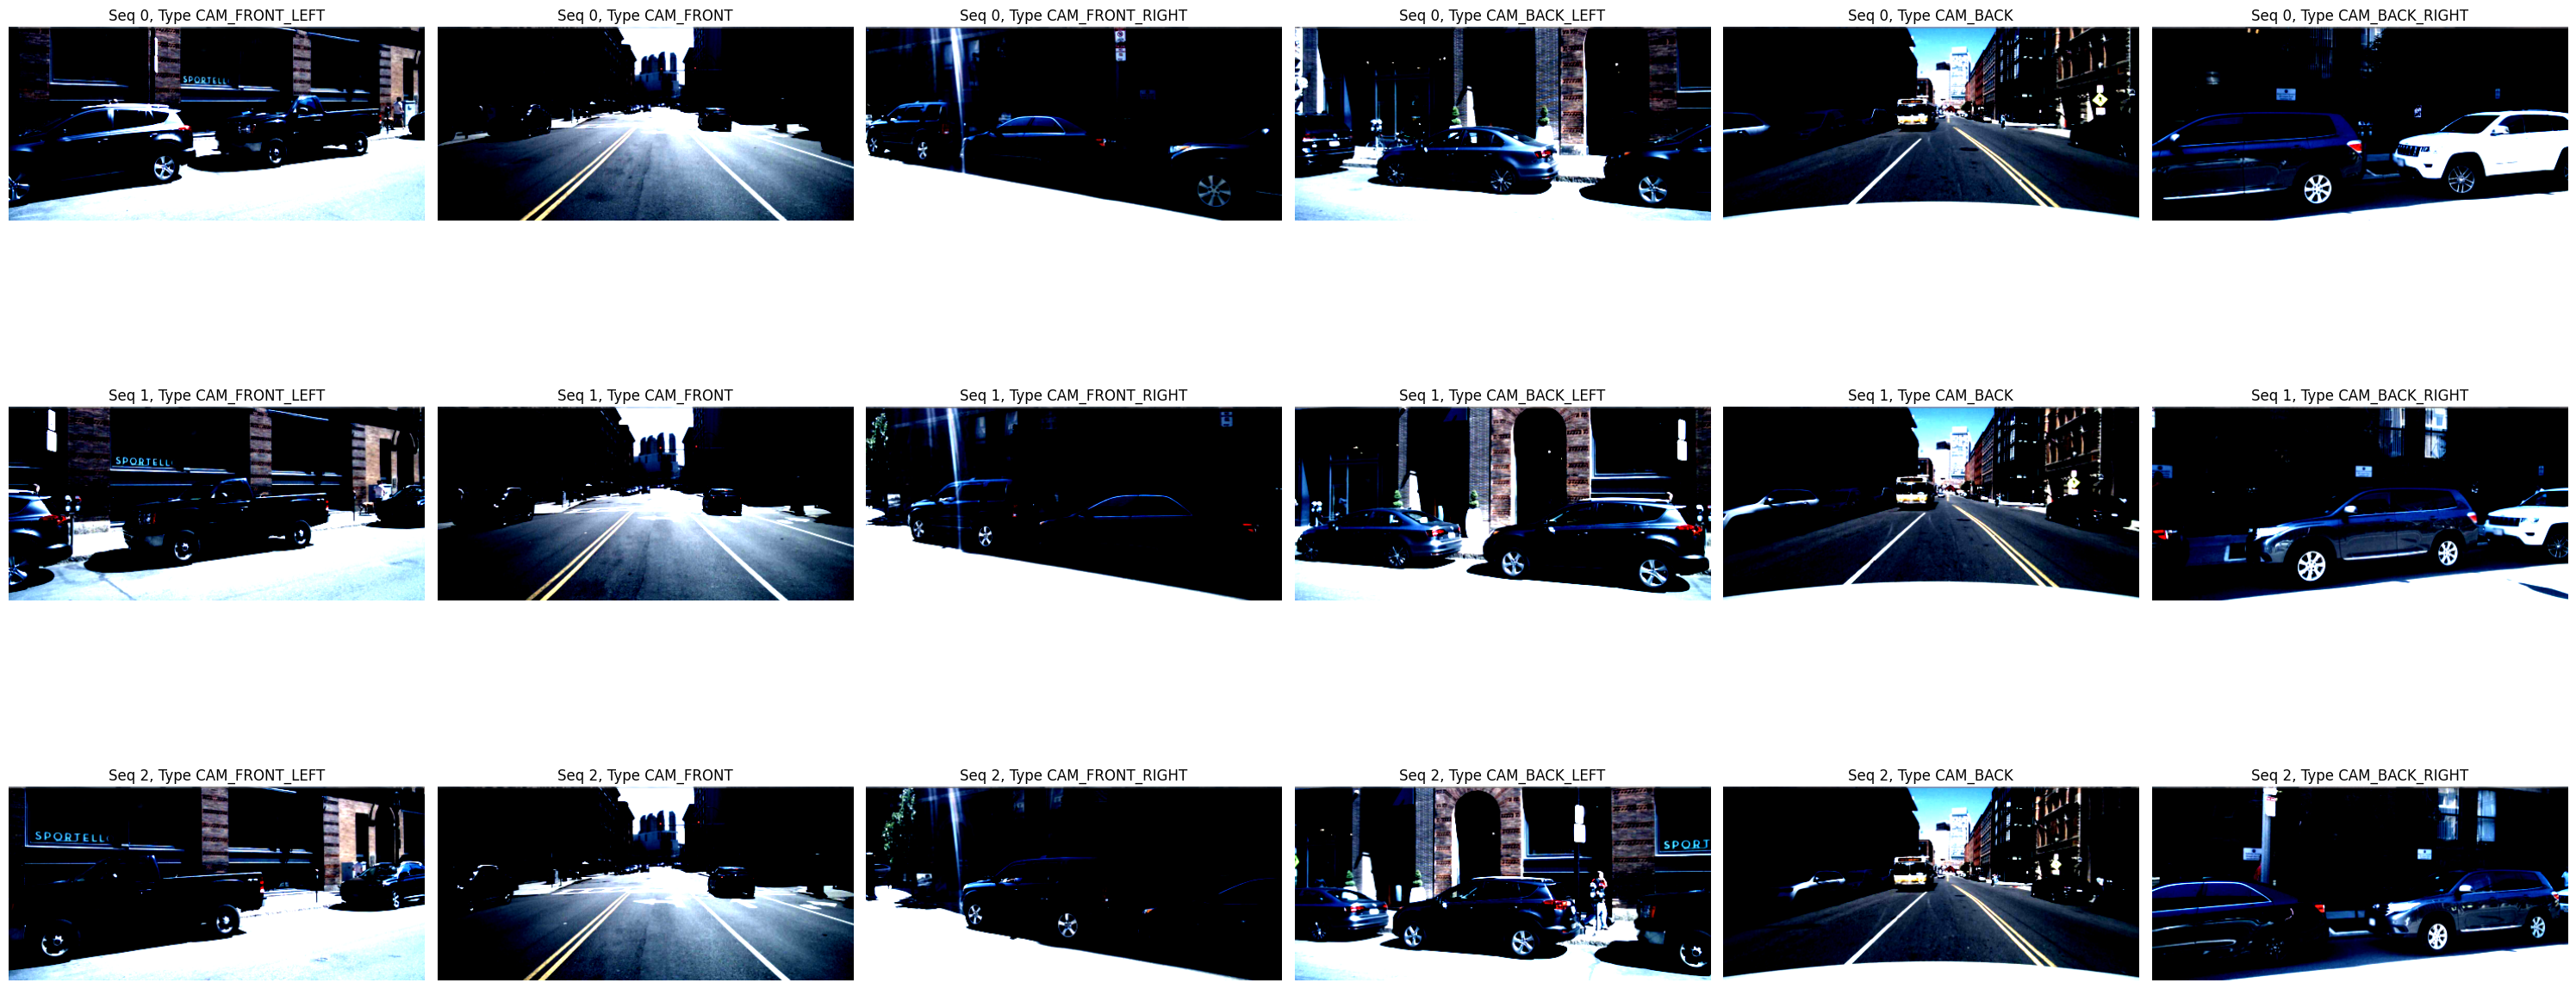

In [ ]:
show_images(sample['image'])

In [13]:
from src.utils.visualisation import plot_instance_map, make_contour, heatmap_image, flow_to_image

In [14]:
output_label_list = ['segmentation', 'instance', 'offset', 'centerness']

output_labels = {label: sample[label] for label in output_label_list}

In [15]:
import numpy as np
def visualise_labels(labels, sequence_length):
    semantic_colours = np.array([[255, 255, 255], [0, 0, 0]], dtype=np.uint8)

    b = 0
    video = []
    for t in range(sequence_length):
        out_t = []
        # Ground truth
        unique_ids = torch.unique(labels['instance'][b, t]).cpu().numpy()[1:]
        instance_map = dict(zip(unique_ids, unique_ids))
        instance_plot = plot_instance_map(labels['instance'][b, t].cpu(), instance_map)[::-1, ::-1]
        instance_plot = make_contour(instance_plot)

        semantic_seg = labels['segmentation'].squeeze(2).cpu().numpy()
        semantic_plot = semantic_colours[semantic_seg[b, t][::-1, ::-1]]
        semantic_plot = make_contour(semantic_plot)

        future_flow_plot = np.zeros_like(semantic_plot)

        center_plot = heatmap_image(labels['centerness'][b, t, 0].cpu().numpy())[::-1, ::-1]
        center_plot = make_contour(center_plot)

        offset_plot = labels['offset'][b, t].cpu().numpy()
        offset_plot[:, semantic_seg[b, t] != 1] = 0
        offset_plot = flow_to_image(offset_plot)[::-1, ::-1]
        offset_plot = make_contour(offset_plot)

        out_t.append(np.concatenate([instance_plot, future_flow_plot,
                                     semantic_plot, center_plot, offset_plot], axis=0))

        video.append(out_t)

    # Shape (B, T, C, H, W)
    video = np.stack(video)[None]

    
    return video

In [16]:
sequence_length = output_labels['instance'].shape[1]
video = visualise_labels(output_labels, sequence_length)

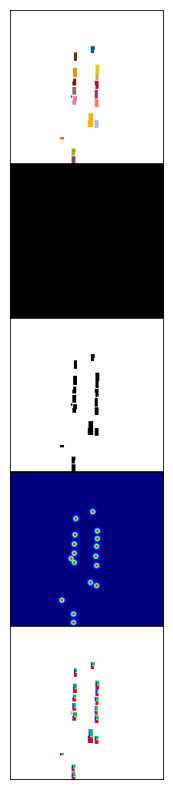

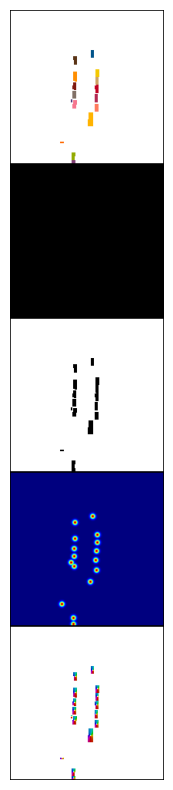

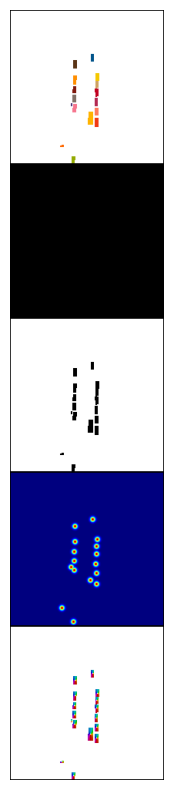

In [17]:
from matplotlib import pyplot as plt
for frame in video[0]:
    plt.figure(figsize=(10, 10))
    plt.imshow(frame[0])
    plt.axis('off')
    plt.show()

#### Now lets do the same for Validation Set

In [19]:
data_val = FuturePredictionDataset(
            data_root=data_root, is_train=False, version=version, batch_size=batch_size, filter_invisible_vehicles=filter_invisible_vehicles, common=common
        )

KeyboardInterrupt: 

In [19]:
val_sample = next(iter(data_val))

In [ ]:
print(val_sample.keys())


In [ ]:
for key in val_sample.keys():
    if isinstance(val_sample[key], torch.Tensor):
        print(key, val_sample[key].shape)

In [22]:
def visualize_video(sample):
    output_label_list = ['segmentation', 'instance', 'offset', 'centerness']

    output_labels = {label: sample[label].unsqueeze(0) for label in output_label_list}



    sequence_length = output_labels['instance'].shape[1]
    video = visualise_labels(output_labels, sequence_length)
    for frame in video[0]:
        plt.figure(figsize=(10, 10))
        plt.imshow(frame[0])
        plt.axis('off')
        plt.show()
    return video

In [ ]:
visualize_video(next(iter(data_val)))